## Summary:

This notebook analyzes the data efficiency of the model by evaluating how performance scales with the size of the training dataset. It visualizes the relationship between the number of training samples and the resulting reconstruction optimization errors, helping to identify the saturation point where additional data provides diminishing returns in accuracy.

## Requirements:

- You need to have generated or saved ham-terms instances 
- You need to have trained or saved models for system sizes ```L=[4,6,8,10,12,14]``` 
- These models have to be trained with ```[900*2*L, 3000*2*L, 9000*2*L, 30000*2*L, 90000*2*L]``` points, respectively.








In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from dftqml.autoencoders.ae import load_model 
import torch
import torch.nn.functional as F
from dftqml.autoencoders import autoencoder_utils

plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.4,
        "ytick.major.width": 0.4,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 8,
    }
)

# Plotting Dataset Scaling

In [3]:
#  Dictionary to store losses: loss_dict[L][ndata] = [loss_fold0, loss_fold1, loss_fold2]
loss_dict = {}

# System sizes to iterate over
L_values = [4, 6, 8, 10, 12, 14]

input_type = "ham_terms"

n_folds = 3

for L in L_values:
    ndata_values = [900, 3000, 9000, 30000, 90000]
    ndata_values_sa = [900*2*L, 3000*2*L, 9000*2*L, 30000*2*L, 90000*2*L]
    loss_dict[L] = {ndata: [] for ndata in ndata_values+ ndata_values_sa }
    z = L - 1  # latent dimension
    
    for ndata in ndata_values:
        for iter in range(n_folds):

            checkpoint_kwargs = dict(
                models_dir="../models/bs256",
                input_type=input_type,
                L=L,
                N=L,
                U=4.0,
                interpolation="geometric",
                enable_batchnorm=False,
                hidden_depth=4,
                latent_dim=z,
                min_dim=L**2,
                scaling_factor=20.0 if input_type == "ham_terms" else 1.0,
                weight_decay=None,
                lambda_latent_norm=1e-7,
                lambda_latent_repulsion=1e-7,
                lambda_lipschitz_encoder=1e-9,
                lambda_lipschitz_decoder=1e-8,
                iteration=iter,
                linear_encoder=False,
                augment_by_symmetry=False
                )

            checkpoint_dir = autoencoder_utils.checkpoint_dir_path(**checkpoint_kwargs)
            try:
                model = load_model(checkpoint_dir, device="cpu")

                # Load test data
                n_test_data = 10000
                data_path = f"../data/L{L}-N{L}-U4.0_reduced.hdf5"

                with h5py.File(data_path, "r") as f:
                    x = f["hamiltonian_terms"][-n_test_data + 1 :]


                # Reshape and compute reconstruction
                input_vector = torch.Tensor(x.reshape((n_test_data - 1, 3 * L)))
                recon_vector = model(input_vector)
                input_vector_original = torch.Tensor(x)

                # Compute MSE loss
                loss = np.sqrt(
                    F.mse_loss(input_vector_original, recon_vector, reduction="mean")
                    .detach()
                    .numpy())
                loss_dict[L][ndata].append(loss)
            except:
                pass

    for ndata in ndata_values_sa:
        for iter in range(n_folds):

            checkpoint_kwargs = dict(
                models_dir="../models/bs256",
                input_type=input_type,
                L=L,
                N=L,
                U=4.0,
                interpolation="geometric",
                enable_batchnorm=False,
                hidden_depth=4,
                latent_dim=z,
                min_dim=L**2,
                scaling_factor=20.0 if input_type == "ham_terms" else 1.0,
                weight_decay=None,
                lambda_latent_norm=1e-7,
                lambda_latent_repulsion=1e-7,
                lambda_lipschitz_encoder=1e-9,
                lambda_lipschitz_decoder=1e-8,
                iteration=iter,
                linear_encoder=False,
                augment_by_symmetry=True,
                n_data=int(ndata/(2*L))
                )

            checkpoint_dir = autoencoder_utils.checkpoint_dir_path(**checkpoint_kwargs)

            try:
                model = load_model(checkpoint_dir, device="cpu")

                # Load test data
                n_test_data = 10000
                data_path = f"../data/L{L}-N{L}-U4.0_reduced.hdf5"

                with h5py.File(data_path, "r") as f:
                    x = f["hamiltonian_terms"][-n_test_data + 1 :]


                # Reshape and compute reconstruction
                input_vector = torch.Tensor(x.reshape((n_test_data - 1, 3 * L)))
                recon_vector = model(input_vector)
                input_vector_original = torch.Tensor(x)

                # Compute MSE loss
                loss = np.sqrt(
                    F.mse_loss(input_vector_original, recon_vector, reduction="mean")
                    .detach()
                    .numpy())
                loss_dict[L][ndata].append(loss)
            except:
                pass

# Compute mean and std for each L and ndata
loss_stats = {}
for L in L_values:
    loss_stats[L] = {"ndata": [], "min": [] , "mean": [], "std": []}
    for ndata in ndata_values:
        
        losses = loss_dict[L][ndata*2*L]
        loss_stats[L]["ndata"].append(ndata*2*L)
        loss_stats[L]["mean"].append(np.mean(losses))
        loss_stats[L]["std"].append(np.std(losses))
        loss_stats[L]["min"].append(np.min(losses))

(tensor(4.1108, grad_fn=<SumBackward0>), tensor(3.5832, grad_fn=<SumBackward0>))
(tensor(4.0479, grad_fn=<SumBackward0>), tensor(3.5949, grad_fn=<SumBackward0>))
(tensor(3.9816, grad_fn=<SumBackward0>), tensor(3.5674, grad_fn=<SumBackward0>))
(tensor(4.0840, grad_fn=<SumBackward0>), tensor(3.6110, grad_fn=<SumBackward0>))
(tensor(4.0820, grad_fn=<SumBackward0>), tensor(3.5423, grad_fn=<SumBackward0>))
(tensor(4.0579, grad_fn=<SumBackward0>), tensor(3.6411, grad_fn=<SumBackward0>))
(tensor(4.1406, grad_fn=<SumBackward0>), tensor(3.6683, grad_fn=<SumBackward0>))
(tensor(3.9588, grad_fn=<SumBackward0>), tensor(3.6174, grad_fn=<SumBackward0>))
(tensor(4.0402, grad_fn=<SumBackward0>), tensor(3.6728, grad_fn=<SumBackward0>))
(tensor(4.0262, grad_fn=<SumBackward0>), tensor(3.5717, grad_fn=<SumBackward0>))
(tensor(4.1090, grad_fn=<SumBackward0>), tensor(3.6808, grad_fn=<SumBackward0>))
(tensor(4.0991, grad_fn=<SumBackward0>), tensor(3.6417, grad_fn=<SumBackward0>))
(tensor(4.1124, grad_fn=<Sum

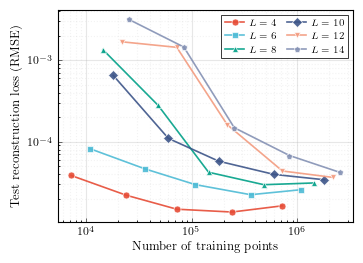

In [4]:
for k, d in loss_stats.items():
    order = np.argsort(d['ndata'])
    for field in d:
        d[field] = [d[field][i] for i in order]


def plot_training_scaling(loss_stats):
    """
    Create a Nature-style plot of training data size vs reconstruction loss.

    Parameters
    ----------
    loss_stats : dict
        Dictionary with keys as system sizes L and values as dicts containing
        'ndata', 'mean', and 'std' arrays

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object
    """
    # Nature single column width (~3.5 inches)
    fig, ax = plt.subplots(figsize=(3.5, 2.5))

    # Nature-style color palette (colorblind-friendly)
    colors = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4"]

    # Marker styles for visual distinction
    markers = ["o", "s", "^", "D", "v", "p"]

    L_values = sorted(loss_stats.keys())

    for idx, L in enumerate(L_values):
        ndata = np.array(loss_stats[L]["ndata"])
        min_loss = np.array(loss_stats[L]["min"])
        std_loss = np.array(loss_stats[L]["std"])

        ndata_values_sa = [900*2*L, 3000*2*L, 9000*2*L, 30000*2*L, 90000*2*L]
        ndata_values_sa = set(ndata_values_sa)

        # Boolean masks
        mask_sa = np.array([x in ndata_values_sa for x in ndata])


        # Plot mean with error bars
        ax.plot(
            ndata[mask_sa],
            min_loss[mask_sa],
            marker=markers[idx],
            markersize=5,
            linewidth=1.2,
            color=colors[idx],
            label=f"$L={L}$",
            markerfacecolor=colors[idx],
            markeredgewidth=0.5,
            markeredgecolor="white",
            alpha=0.9,
        )

    # Set log scale for both axes
    ax.set_xscale("log")
    ax.set_yscale("log")

    # Add grid
    ax.grid(True, which="major", linestyle="-", alpha=0.3)
    ax.grid(True, which="minor", linestyle=":", alpha=0.15)

    # Labels
    ax.set_xlabel(r"Number of training points", fontsize=9)
    ax.set_ylabel(r"Test reconstruction loss (RMSE)", fontsize=9)

    # Legend with Nature style
    legend = ax.legend(
        frameon=True,
        loc="best",
        fontsize=7,
        ncol=2,
        columnspacing=1.0,
        handletextpad=0.5,
        framealpha=0.9,
        edgecolor="black",
        fancybox=False,
    )
    legend.get_frame().set_linewidth(0.6)

    # Tick parameters
    ax.tick_params(direction="in", which="both", labelsize=8)
    ax.tick_params(which="major", length=3)
    ax.tick_params(which="minor", length=1.5)

    # Add minor ticks
    ax.minorticks_on()

    # Spine customization
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    fig.tight_layout(pad=0.3)

    return fig

fig = plot_training_scaling(loss_stats)
# fig.savefig("training_scaling_loss.pdf", dpi=300, bbox_inches="tight")